In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PREFIX = "inertial-6286.188861:"

def read_csv(csv_path_file):
    buff = []
    with open(csv_path_file, "r") as file:
    # with open("CB_ARW.csv", "r") as file:
        data = False
        for line in file:
            
            if line == "DATA_START\n":
                data = True
                continue
            
            if data == True:
                line = line.rstrip()
                values = line.split(",")
                buff.append(values)

    header = [b.lstrip(PREFIX) for b in buff[0]]

    buff = np.array(buff)

    df = pd.DataFrame(data=buff[1:], columns=header)
    
    cols_to_drop = [c for c in df.columns if c.endswith('valid')]
    df = df.drop(columns=cols_to_drop)

    # Conversion de tipo de datos de df (string a numerico)
    for column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    return df

fs = 100
dt = 1 / fs


In [ ]:
df_cuat = read_csv(r"pruebas_oficina_29-04\cuate_est_2.csv")

df_imu = read_csv(r"pruebas_oficina_29-04\imu_2     .csv")

start_time_hhmmss = "16:19:20.26"

zupt_periods_hhmmss = [
    ("16:19:20.26", "16:19:38.00"),
    ("16:20:15.00", "16:20:35.00"),
    ("16:21:05.00", "16:21:33.67"),
]

In [17]:
# Renombrar columnas
cuat_new_names = ["q0", "q1", "q2", "q3"]
df_cuat = df_cuat.rename(columns=dict(zip(df_cuat.columns[1:], cuat_new_names)))

# Tiempo relativo en segundos
df_cuat["t"] = (df_cuat["Time"] - df_cuat["Time"].iloc[0]) / 1e9

# Delta de tiempo entre muestras
df_cuat["dt"] = df_cuat["t"].diff()

# Reordenar columnas
df_cuat = df_cuat.reindex(columns=['Time', 't', 'dt', 'q0', 'q1', 'q2', 'q3'])

df_cuat

,Time,t,dt,q0,q1,q2,q3
0,1777498111089049856,0.000000,NaN,0.013344,0.004088,0.001913,0.999901
1,1777498111098727424,0.009678,0.009678,0.013342,0.004087,0.001914,0.999901
2,1777498111108385792,0.019336,0.009658,0.013339,0.004087,0.001915,0.999901
3,1777498111118024960,0.028975,0.009639,0.013338,0.004088,0.001916,0.999901
4,1777498111127645696,0.038596,0.009621,0.013338,0.004088,0.001920,0.999901
...,...,...,...,...,...,...,...
9596,1777498206937280768,95.848231,0.009885,0.003119,0.005192,0.000475,0.999982
9597,1777498206947146496,95.858097,0.009866,0.003124,0.005189,0.000472,0.999982
9598,1777498206956993280,95.867943,0.009847,0.003129,0.005192,0.000476,0.999982
9599,1777498206966820864,95.877771,0.009828,0.003131,0.005197,0.000476,0.999981


In [18]:
al_new_names = ["alx", "aly", "alz"]

df_imu = df_imu.rename(columns=dict(zip(df_imu.columns[1:], al_new_names)))

df_imu

,Time,alx,aly,alz
0,1777498111089049856,0.004354,0.002267,0.038142
1,1777498111098727424,-0.001516,-0.000712,0.037144
2,1777498111108385792,-0.004611,-0.009878,0.045220
3,1777498111118024960,-0.007349,-0.009608,0.048336
4,1777498111127645696,-0.011816,-0.007393,0.036819
...,...,...,...,...
9596,1777498206937280768,-0.016743,-0.001144,0.052367
9597,1777498206947146496,-0.018038,0.004665,0.046031
9598,1777498206956993280,-0.019027,0.003047,0.042640
9599,1777498206966820864,-0.013755,0.002514,0.037555


In [19]:
tol_ns = 5_000_000  # 5 ms

df_u = pd.merge_asof(
    df_cuat,
    df_imu,
    on="Time",
    direction="nearest",
    tolerance=tol_ns
)

# Eliminar filas donde no hubo coincidencia dentro de la tolerancia
df_u = df_u.dropna(
    subset=["q0"]
).reset_index(drop=True)

df_u

,Time,t,dt,q0,q1,q2,q3,alx,aly,alz
0,1777498111089049856,0.000000,NaN,0.013344,0.004088,0.001913,0.999901,0.004354,0.002267,0.038142
1,1777498111098727424,0.009678,0.009678,0.013342,0.004087,0.001914,0.999901,-0.001516,-0.000712,0.037144
2,1777498111108385792,0.019336,0.009658,0.013339,0.004087,0.001915,0.999901,-0.004611,-0.009878,0.045220
3,1777498111118024960,0.028975,0.009639,0.013338,0.004088,0.001916,0.999901,-0.007349,-0.009608,0.048336
4,1777498111127645696,0.038596,0.009621,0.013338,0.004088,0.001920,0.999901,-0.011816,-0.007393,0.036819
...,...,...,...,...,...,...,...,...,...,...
9596,1777498206937280768,95.848231,0.009885,0.003119,0.005192,0.000475,0.999982,-0.016743,-0.001144,0.052367
9597,1777498206947146496,95.858097,0.009866,0.003124,0.005189,0.000472,0.999982,-0.018038,0.004665,0.046031
9598,1777498206956993280,95.867943,0.009847,0.003129,0.005192,0.000476,0.999982,-0.019027,0.003047,0.042640
9599,1777498206966820864,95.877771,0.009828,0.003131,0.005197,0.000476,0.999981,-0.013755,0.002514,0.037555


In [20]:
# Validación

print(df_u["dt"].describe())

fs_mean = 1 / df_u["dt"].iloc[1:].mean()
print(f"Frecuencia promedio: {fs_mean:.2f} Hz")

count    9600.000000
mean        0.009988
std         0.000133
min         0.009560
25%         0.009881
50%         0.009995
75%         0.010096
max         0.010231
Name: dt, dtype: float64
Frecuencia promedio: 100.12 Hz


In [21]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R


def is_in_zupt_period(t, zupt_periods):
    """
    Verifica si el tiempo t está dentro de algún periodo ZUPT.

    zupt_periods:
        Lista de tuplas [(t_ini, t_fin), ...]
        Ejemplo:
            [(0, 5), (45, 55), (120, 130)]
    """
    if zupt_periods is None:
        return False

    for t_ini, t_fin in zupt_periods:
        if t_ini <= t <= t_fin:
            return True

    return False


def ins_strapdown_dead_reckoning(
    df,
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    time_col="t",
    dt_col="dt",

    # Ganancias generales
    G_acc=1.0,
    p_gain=1.0,

    # ZUPT manual por tiempo
    zupt_periods=None,
    ZUPT_GAIN=1.0,
    hard_zupt=True,

    # Non-Holonomic Constraints
    use_nhc=True,
    K_nhc_y=0.9,
    K_nhc_z=0.9,

    # Convención de rotación
    use_transpose=True,

    # Opciones
    normalize_quat=True,
    verbose=True
):
    """
    INS strapdown básico para Dead Reckoning usando:
        - aceleración lineal en body
        - cuaternión de orientación
        - ZUPT manual por ventanas de tiempo
        - NHC para vehículo terrestre

    Parámetros
    ----------
    df : pd.DataFrame
        Debe contener columnas:
            Time, t, dt, q0, q1, q2, q3, alx, aly, alz

    acc_cols : tuple
        Columnas de aceleración lineal en body.

    quat_cols : tuple
        Columnas del cuaternión.
        Se asume:
            q0 = componente escalar w
            q1, q2, q3 = componentes vectoriales x, y, z

    time_col : str
        Columna de tiempo relativo en segundos.

    dt_col : str
        Columna de delta tiempo en segundos.

    zupt_periods : list of tuple
        Periodos donde se aplica ZUPT.
        Ejemplo:
            zupt_periods = [(0, 5), (45, 55), (100, 110)]

    ZUPT_GAIN : float
        Ganancia de corrección de velocidad.
        Si hard_zupt=True, la velocidad se fuerza a cero.
        Si hard_zupt=False, se aplica:
            v = v - ZUPT_GAIN * v

    hard_zupt : bool
        True  -> fuerza v = 0 durante ZUPT.
        False -> reduce velocidad suavemente según ZUPT_GAIN.

    use_nhc : bool
        Aplica restricciones no holonómicas.

    K_nhc_y : float
        Ganancia para reducir velocidad lateral en body.

    K_nhc_z : float
        Ganancia para reducir velocidad vertical en body.

    use_transpose : bool
        Si True:
            R_nb = r.as_matrix().T
        Si False:
            R_nb = r.as_matrix()

        Se deja como True porque coincide con tu script original.

    Retorna
    -------
    df_out : pd.DataFrame
        DataFrame con columnas agregadas:
            a_nav_x, a_nav_y, a_nav_z
            v_int_x, v_int_y, v_int_z
            vx_body_raw, vy_body_raw, vz_body_raw
            vx_body_nhc, vy_body_nhc, vz_body_nhc
            vx, vy, vz
            px, py, pz
            px_scale, py_scale, pz_scale
            zupt_flag
    """

    df_out = df.copy()

    # Inicialización
    p = np.zeros(3, dtype=float)
    v = np.zeros(3, dtype=float)

    # Crear columnas de salida
    output_cols = [
        "a_nav_x", "a_nav_y", "a_nav_z",
        "v_int_x", "v_int_y", "v_int_z",
        "vx_body_raw", "vy_body_raw", "vz_body_raw",
        "vx_body_nhc", "vy_body_nhc", "vz_body_nhc",
        "vx", "vy", "vz",
        "px", "py", "pz",
        "px_scale", "py_scale", "pz_scale",
        "zupt_flag"
    ]

    for col in output_cols:
        df_out[col] = np.nan

    # Loop strapdown
    for k in range(len(df_out)):

        t = df_out.loc[k, time_col]
        dt = df_out.loc[k, dt_col]

        # Para la primera fila normalmente dt es NaN
        if pd.isna(t) or pd.isna(dt) or dt <= 0:
            df_out.loc[k, ["vx", "vy", "vz"]] = v
            df_out.loc[k, ["px", "py", "pz"]] = p
            df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_gain * p
            df_out.loc[k, "zupt_flag"] = 0
            continue

        # -----------------------------
        # 1. Leer aceleración en body
        # -----------------------------
        a_body = df_out.loc[k, list(acc_cols)].to_numpy(dtype=float)

        # -----------------------------
        # 2. Leer y normalizar cuaternión
        # -----------------------------
        q = df_out.loc[k, list(quat_cols)].to_numpy(dtype=float)

        q_norm = np.linalg.norm(q)

        if normalize_quat:
            q = q / q_norm

        q0, q1, q2, q3 = q

        # scipy usa formato [x, y, z, w]
        r = R.from_quat([q1, q2, q3, q0])

        if use_transpose:
            R_nb = r.as_matrix().T
        else:
            R_nb = r.as_matrix()

        # -----------------------------
        # 3. Aceleración body -> navegación
        # -----------------------------
        a_nav = G_acc * (R_nb @ a_body)

        df_out.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = a_nav

        # -----------------------------
        # 4. Integración de velocidad libre
        # -----------------------------
        v = v + a_nav * dt

        df_out.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v

        # -----------------------------
        # 5. ZUPT manual po r periodos
        # -----------------------------
        zupt_flag = int(is_in_zupt_period(t, zupt_periods))
        df_out.loc[k, "zupt_flag"] = zupt_flag

        if zupt_flag == 1:
            if hard_zupt:
                v[:] = 0.0
            else:
                v = v - ZUPT_GAIN * v

        # -----------------------------
        # 6. NHC: velocidad nav -> body
        # -----------------------------
        if use_nhc:
            v_body = R_nb.T @ v

            df_out.loc[k, ["vx_body_raw", "vy_body_raw", "vz_body_raw"]] = v_body

            # Restricción no holonómica:
            # vehículo no debería desplazarse lateral ni verticalmente
            v_body[1] = v_body[1] * (1.0 - K_nhc_y)
            v_body[2] = v_body[2] * (1.0 - K_nhc_z)

            df_out.loc[k, ["vx_body_nhc", "vy_body_nhc", "vz_body_nhc"]] = v_body

            # Volver a navegación
            v = R_nb @ v_body

        # -----------------------------
        # 7. Integración de posición
        # -----------------------------
        p = p + v * dt

        p_scale = p_gain * p

        df_out.loc[k, ["vx", "vy", "vz"]] = v
        df_out.loc[k, ["px", "py", "pz"]] = p
        df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_scale

    if verbose:
        print("INS strapdown finalizado.")
        print(f"Filas procesadas: {len(df_out)}")
        print(f"Posición final [m]: {p}")
        print(f"Velocidad final [m/s]: {v}")

    return df_out

In [22]:
import pandas as pd
import numpy as np


def hhmmss_to_seconds(hhmmss):
    """
    Convierte una hora tipo:
        '16:46:25.77'
        '16:47:00.7'
        '16:47:27'
    a segundos desde las 00:00:00.
    """

    parts = hhmmss.strip().split(":")

    if len(parts) != 3:
        raise ValueError(f"Formato inválido: {hhmmss}. Usa HH:MM:SS.sss")

    h = int(parts[0])
    m = int(parts[1])
    s = float(parts[2])

    return h * 3600 + m * 60 + s


def convert_zupt_periods_hhmmss_to_relative(zupt_periods_hhmmss, start_time_hhmmss):
    """
    Convierte periodos ZUPT dados en hora real HH:MM:SS.sss
    a periodos relativos en segundos respecto a start_time_hhmmss.

    Ejemplo:
        start_time_hhmmss = '16:46:09.77'

        zupt_periods_hhmmss = [
            ('16:46:25.77', '16:46:30.25'),
            ('16:46:52.64', '16:47:00.7')
        ]

    Retorna:
        [
            (16.0, 20.48),
            (42.87, 50.93)
        ]
    """

    t0_abs = hhmmss_to_seconds(start_time_hhmmss)

    zupt_periods_rel = []

    for t_ini_str, t_fin_str in zupt_periods_hhmmss:
        t_ini_abs = hhmmss_to_seconds(t_ini_str)
        t_fin_abs = hhmmss_to_seconds(t_fin_str)

        t_ini_rel = t_ini_abs - t0_abs
        t_fin_rel = t_fin_abs - t0_abs

        if t_fin_rel < t_ini_rel:
            raise ValueError(
                f"Periodo inválido: {t_ini_str} - {t_fin_str}. "
                "El tiempo final es menor que el inicial."
            )

        zupt_periods_rel.append((t_ini_rel, t_fin_rel))

    return zupt_periods_rel

In [23]:
zupt_periods = convert_zupt_periods_hhmmss_to_relative(
    zupt_periods_hhmmss,
    start_time_hhmmss
)

print(zupt_periods)

[(0.0, 17.739999999997963), (54.73999999999796, 74.73999999999796), (104.73999999999796, 133.40999999999622)]


In [24]:
# # Periodos donde sabes que el vehículo está detenido

# zupt_periods = [
#     #  t_inicio, t_final
#     (0, 18),    # detenido al inicio
#     (55, 75),
#     (105, 133),  # detenido al final
# ]

In [25]:
df_ins = ins_strapdown_dead_reckoning(
    df=df_u,
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    time_col="t",
    dt_col="dt",

    G_acc=1.0,
    p_gain=1.0,

    zupt_periods=zupt_periods,
    ZUPT_GAIN=1.0,
    hard_zupt=True,

    use_nhc=True,
    K_nhc_y=0.9,
    K_nhc_z=0.9,

    use_transpose=True
)

df_ins.head()

INS strapdown finalizado.
Filas procesadas: 9601
Posición final [m]: [ 3.85609931 37.22452204  0.33803621]
Velocidad final [m/s]: [-1.13497008 -0.00711634  0.01185705]


,Time,t,dt,q0,q1,q2,q3,alx,aly,alz,...,vx,vy,vz,px,py,pz,px_scale,py_scale,pz_scale,zupt_flag
0,1777498111089049856,0.000000,NaN,0.013344,0.004088,0.001913,0.999901,0.004354,0.002267,0.038142,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1777498111098727424,0.009678,0.009678,0.013342,0.004087,0.001914,0.999901,-0.001516,-0.000712,0.037144,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1777498111108385792,0.019336,0.009658,0.013339,0.004087,0.001915,0.999901,-0.004611,-0.009878,0.045220,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1777498111118024960,0.028975,0.009639,0.013338,0.004088,0.001916,0.999901,-0.007349,-0.009608,0.048336,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1777498111127645696,0.038596,0.009621,0.013338,0.004088,0.001920,0.999901,-0.011816,-0.007393,0.036819,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [26]:
df_ins

,Time,t,dt,q0,q1,q2,q3,alx,aly,alz,...,vx,vy,vz,px,py,pz,px_scale,py_scale,pz_scale,zupt_flag
0,1777498111089049856,0.000000,NaN,0.013344,0.004088,0.001913,0.999901,0.004354,0.002267,0.038142,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,1777498111098727424,0.009678,0.009678,0.013342,0.004087,0.001914,0.999901,-0.001516,-0.000712,0.037144,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
2,1777498111108385792,0.019336,0.009658,0.013339,0.004087,0.001915,0.999901,-0.004611,-0.009878,0.045220,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
3,1777498111118024960,0.028975,0.009639,0.013338,0.004088,0.001916,0.999901,-0.007349,-0.009608,0.048336,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
4,1777498111127645696,0.038596,0.009621,0.013338,0.004088,0.001920,0.999901,-0.011816,-0.007393,0.036819,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9596,1777498206937280768,95.848231,0.009885,0.003119,0.005192,0.000475,0.999982,-0.016743,-0.001144,0.052367,...,-1.135560,-0.007075,0.011852,3.900766,37.224802,0.337570,3.900766,37.224802,0.337570,0.0
9597,1777498206947146496,95.858097,0.009866,0.003124,0.005189,0.000472,0.999982,-0.018038,0.004665,0.046031,...,-1.135382,-0.007092,0.011839,3.889564,37.224732,0.337687,3.889564,37.224732,0.337687,0.0
9598,1777498206956993280,95.867943,0.009847,0.003129,0.005192,0.000476,0.999982,-0.019027,0.003047,0.042640,...,-1.135194,-0.007101,0.011838,3.878386,37.224662,0.337804,3.878386,37.224662,0.337804,0.0
9599,1777498206966820864,95.877771,0.009828,0.003131,0.005197,0.000476,0.999981,-0.013755,0.002514,0.037555,...,-1.135059,-0.007105,0.011842,3.867232,37.224592,0.337920,3.867232,37.224592,0.337920,0.0


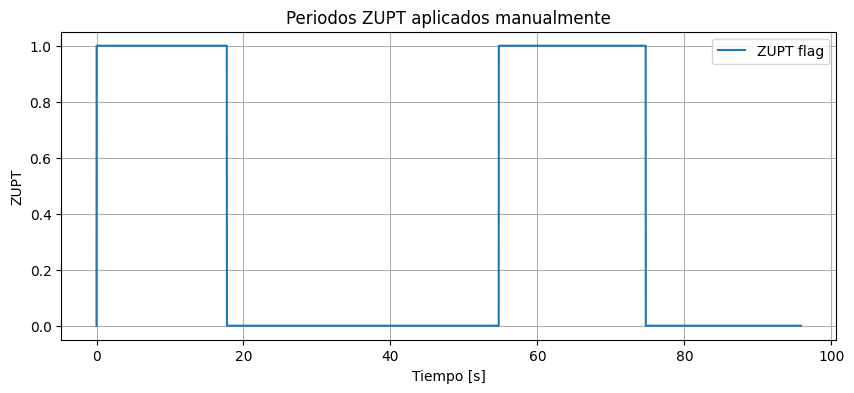

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(df_ins["t"], df_ins["zupt_flag"], label="ZUPT flag")
plt.xlabel("Tiempo [s]")
plt.ylabel("ZUPT")
plt.title("Periodos ZUPT aplicados manualmente")
plt.grid(True)
plt.legend()
plt.show()

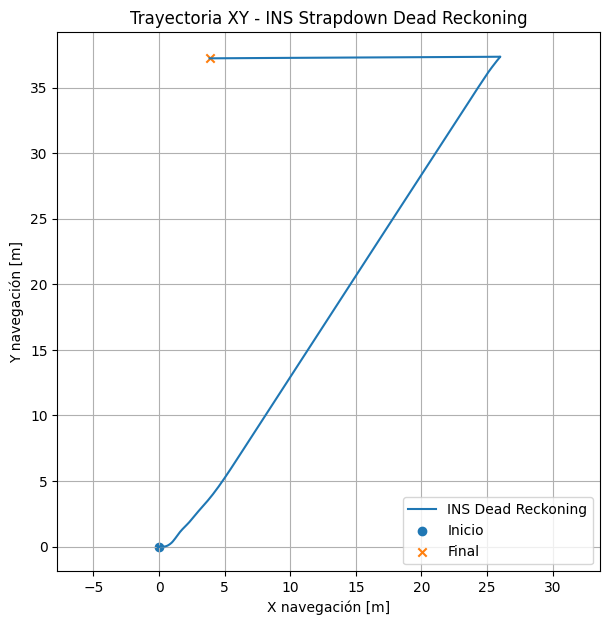

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.plot(df_ins["px"], df_ins["py"], label="INS Dead Reckoning")

plt.scatter(df_ins["px"].iloc[0], df_ins["py"].iloc[0], label="Inicio", marker="o")
plt.scatter(df_ins["px"].iloc[-1], df_ins["py"].iloc[-1], label="Final", marker="x")

plt.xlabel("X navegación [m]")
plt.ylabel("Y navegación [m]")
plt.title("Trayectoria XY - INS Strapdown Dead Reckoning")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()